# Seaborn ile Doğrusal Regresyon

🚀 Seaborn kullanarak Doğrusal Regresyon analizine görsel olarak başlayalım!

Hedefimiz aşağıdakilerin ilk anlayışını elde etmektir:
- `orders` özelikleri ve
- onlarla ilişkili `review_scores`

In [40]:
import os
os.getcwd()

'C:\\Users\\rerso\\Downloads'

In [42]:
import os

for root, dirs, files in os.walk(r"C:\Users\rerso"):
    for f in files:
        if "olist_orders" in f.lower() or "olist_order_reviews" in f.lower():
            print(os.path.join(root, f))

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# Import Modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
import os
os.getcwd()

'C:\\Users\\rerso\\Downloads'

In [30]:
os.listdir()

['.ipynb_checkpoints',
 '2. Query_databases_Challenge.ipynb',
 '2. Query_databases_Challenge_Solution.ipynb',
 '2025_bireysel.xlsx',
 '2025_milli (1).xlsx',
 '2025_milli.xlsx',
 'acquisition_facebook_adds (1).csv',
 'acquisition_facebook_adds.csv',
 'Anaconda3-2024.10-1-Windows-x86_64.exe',
 'Anaconda3-2025.12-2-Windows-x86_64.exe',
 'archive (1).zip',
 'archive (2).zip',
 'archive.zip',
 'Aybuke_Altuntas_Updated_CV_final.docx (1) (1).docx',
 'Aybuke_Altuntas_Updated_CV_final.docx (1).docx',
 'Aybuke_Altuntas_Updated_CV_final.docx.docx',
 'Başlıksız e-tablo (1).xlsx',
 'Başlıksız e-tablo.xlsx',
 'BIGQUERY PROJECT NAME AND PROJECT ID - LAZIM SQL ICIN.docx',
 'bquxjob_7b39de52_19bf696e1b8.csv',
 'branches.csv',
 'Business_sector (1).xlsx',
 'Business_sector.xlsx',
 'CALISMA3- 4 KASIM 2025.docx',
 'categories.csv',
 'ChromeSetup (1).exe',
 'ChromeSetup (2).exe',
 'ChromeSetup.exe',
 'confident-coder-476807-t1-11c2a0df85c5.json',
 'confident-coder-476807-t1-645d1f972fe0.json',
 'confident-

In [32]:
import os

for f in os.listdir():
    if "reg" in f.lower() or "olist" in f.lower() or "analysis" in f.lower():
        print(f)

data-seaborn-regression-main (1).zip
data-seaborn-regression-main.zip
seaborn_regression.ipynb


In [34]:
import os

os.path.exists("seaborn_regression.ipynb")

True

In [36]:
import zipfile

with zipfile.ZipFile("data-seaborn-regression-main.zip", "r") as z:
    print(z.namelist())

['data-seaborn-regression-main/', 'data-seaborn-regression-main/.gitignore', 'data-seaborn-regression-main/README.md', 'data-seaborn-regression-main/seaborn_regression.ipynb']


In [44]:
import os

path = r"C:\Users\rerso\OneDrive\Desktop\WORKINTECH\Veri Analizi ve İstatistiksel Temeller\olist"

os.listdir(path)

['olist', 'olist1.zip']

In [46]:
import os

path = r"C:\Users\rerso\OneDrive\Desktop\WORKINTECH\Veri Analizi ve İstatistiksel Temeller\olist\olist"

os.listdir(path)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [48]:
import pandas as pd

path = r"C:\Users\rerso\OneDrive\Desktop\WORKINTECH\Veri Analizi ve İstatistiksel Temeller\olist\olist"

orders = pd.read_csv(f"{path}\\olist_orders_dataset.csv")
reviews = pd.read_csv(f"{path}\\olist_order_reviews_dataset.csv")
order_items = pd.read_csv(f"{path}\\olist_order_items_dataset.csv")

print("Orders :", orders.shape)
print("Reviews:", reviews.shape)
print("Items  :", order_items.shape)

Orders : (99441, 8)
Reviews: (99224, 7)
Items  : (112650, 7)


In [50]:
orders = orders.copy()

orders = orders[
    orders["order_status"] == "delivered"
].copy()

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

orders["wait_time"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

orders["delay_vs_expected"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

orders["delay_vs_expected"] = orders["delay_vs_expected"].clip(lower=0)

orders[[
    "order_id",
    "wait_time",
    "delay_vs_expected"
]].head()

,order_id,wait_time,delay_vs_expected
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,0.0


In [52]:
orders[[
    "wait_time",
    "delay_vs_expected"
]].describe()

,wait_time,delay_vs_expected
count,96470.000000,96470.000000
mean,12.558217,0.774875
std,9.546156,4.753087
min,0.533414,0.000000
25%,6.766204,0.000000
50%,10.217477,0.000000
75%,15.720182,0.000000
max,209.628611,188.975081


⚠️ Devam etmeden önce:
* 💾 Önceki ünitenin Orders challenge'ının çözümünü indirin
* 👥 `order_solution.py` dosyasının içeriğini `olist/order.py` dosyanıza kopyala-yapıştır yapın

⚠️ `olist` deponuzda `order.py` dosyasındaki kod değişikliklerini commit etmeyi unutmayın!

👇 Öncelikle `orders` veri setini içeri aktarın

## 1 - Özellik Korelasyonunu İnceleme

❓Özellikler arasındaki çeşitli korelasyonları inceleyin: hangi özellik `review_score` ile en çok korelasyonlu görünüyor?

<details>
    <summary>▸ İpucu</summary>

* `DataFrame.corr(numeric_only=True)` kullanın `sns.heatmap()` ve `cmap='coolwarm'` ile kombinasyon yaparak
* `review_score` ile her bir özellik arasındaki korelasyon katsayılarının mutlak değerlerine bakın,
    * katsayı ne kadar yüksekse, verilen özellik `review_score` ile o kadar çok korelasyonludur (pozitif veya negatif)

</details>

In [54]:
reviews[[
    "order_id",
    "review_score"
]].head()

,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5


In [58]:
data = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

data.shape

(96361, 11)

In [60]:
data[[
    "wait_time",
    "delay_vs_expected",
    "review_score"
]].corr()

,wait_time,delay_vs_expected,review_score
wait_time,1.000000,0.702802,-0.333758
delay_vs_expected,0.702802,1.000000,-0.272281
review_score,-0.333758,-0.272281,1.000000


In [62]:
#Review score ile en güçlü negatif ilişki wait_time değişkeninde görülmektedir (corr = -0.334). Bu sonuç teslimat süresi arttıkça müşteri memnuniyetinin azaldığını göstermektedir. Delay_vs_expected değişkeni de review score ile negatif ilişkilidir (corr = -0.272). Siparişlerin tahmini teslim tarihini aşması müşteri değerlendirmelerini olumsuz etkilemektedir. Ayrıca wait_time ile delay_vs_expected arasında güçlü pozitif korelasyon bulunmaktadır (corr = 0.703), bu da uzun teslimat sürelerinin gecikmelerle yakından ilişkili olduğunu göstermektedir.

* 😏 _Kaptan Açık :_
    * `review_score` kendisiyle %100 korelasyonludur
    * ve `dim_is_one_star` ve `dim_is_five_star` ile güçlü korelasyonludur...
* ⚠️ `review_score` ile ilgili sonraki iki en yüksek korelasyon katsayısı :
    * `wait_time` : - %34
    * `delay_vs_expected` : - %27

## 2. `review_score` ile teslimat süresi arasında Doğrusal Regresyon

👉 Görünüşe göre `review_score` çoğunlukla `wait_time` (= - %34) ve `delay_vs_expected` (- %27) ile korelasyonludur.

🎨 Bu korelasyonları `seaborn` ile araştıralım

### 2.1 Grafikler
❓ Sırasıyla `review_score` ile `wait_time` ve `delay_vs_expected` arasında regresyon yapan 2 grafik oluşturun.

<u>İpuçları</u>:

- Hız açısından veri çerçevesini rastgele bir `10.000 satırlık örneğe` indirin (veri keşiflemede iyi bir uygulama)
- Gerekirse her yürütmede örneği değiştirilmekten kaçınmak için `DataFrame.sample()` sabit bir `random_state` ile kullanın
- Regresyon `lines` çizmek için `sns.regplot()` kullanın
- Saçılım grafiğinin yoğunluğunu daha iyi görselleştirmek için bazı `y_jitter` parametreleri ekleyin
- `sns.regplot()` hemen sonrasına bunu ekleyerek `xlim` ve `ylim` sınırlayın (aynı hücrede):
  ```python
  plt.xlim(right=70)
  plt.ylim(bottom=0)
  ```

<Axes: xlabel='wait_time', ylabel='review_score'>

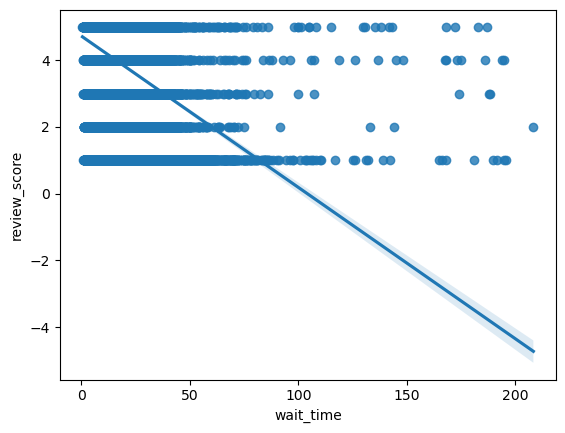

In [64]:
sns.regplot(
    data=data,
    x="wait_time",
    y="review_score"
)

<Axes: xlabel='delay_vs_expected', ylabel='review_score'>

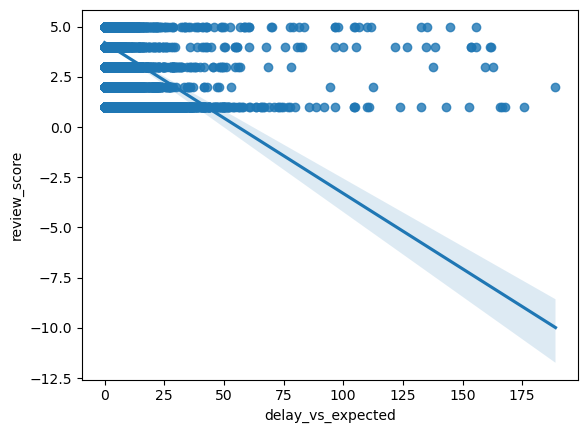

In [68]:
sns.regplot(
    data=data,
    x="delay_vs_expected",
    y="review_score"
)

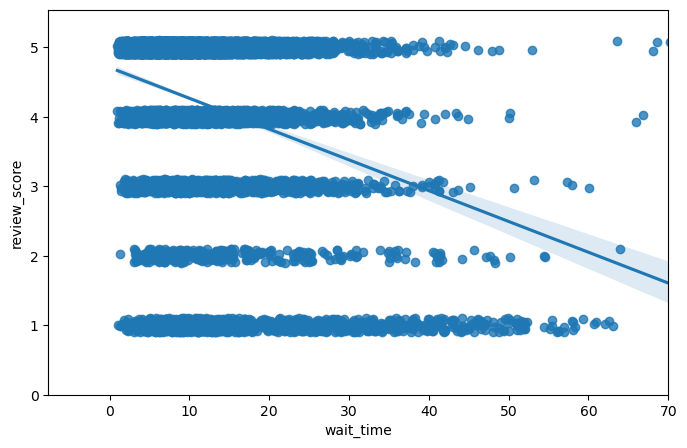

In [70]:
sample = data.sample(
    n=10000,
    random_state=42
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.regplot(
    data=sample,
    x="wait_time",
    y="review_score",
    y_jitter=0.1
)

plt.xlim(right=70)
plt.ylim(bottom=0)

plt.show()

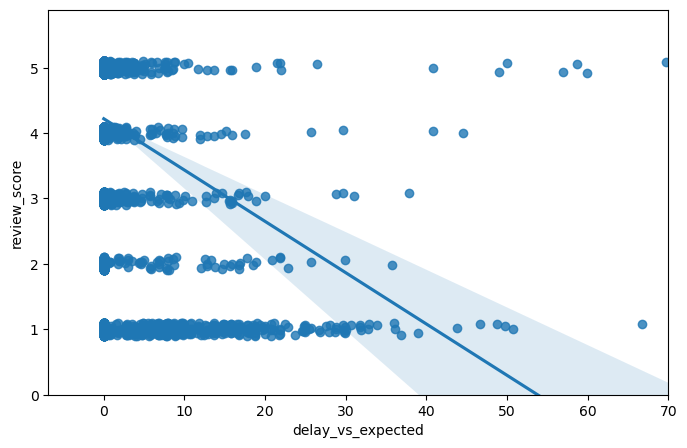

In [72]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=sample,
    x="delay_vs_expected",
    y="review_score",
    y_jitter=0.1
)

plt.xlim(right=70)
plt.ylim(bottom=0)

plt.show()

ℹ️ `regplot` ne yaptı ? 

👉 `review_score` ile `wait_time` ve `delay_vs_exp` arasında `Doğrusal Regresyon` yapmaya çalıştı

🧐 Pek yorumlanabilir görünmüyor, değil mi ?

👉 Haklısınız: sadece 5 farklı review skoru vardır ve bunlar beş farklı olası değeri olan kategorisel bir değişken olarak yorumlanabilir (örneğin: "çok kötü", "kötü", "orta", "iyi" ve "çok iyi") ve `wait_time` ve `delay_vs_exp` olan iki sürekli değere karşı regresyon yapmaya çalışıyoruz.

👀 Ancak regresyon çizgilerine göre çok sezgisel bir desen görebiliriz: bekleme süresi ve/veya gecikme ne kadar uzunsa, review skoru o kadar düşüktür - şaşırtıcı değil. Ama review skoru ne kadar hızlı düşüyor ?

### 2.2 Yorumlama

❓Her eğrinin `eğimini` görsel olarak "hesaplamaya" çalışın. 

✍️ Bu katsayıları veri eğitimi almamış bir kitleye açıklamış olsaydınız, bunları nasıl yorumlayacağınızı yazın.

<details>
    <summary>Cevap</summary>

- `Slope wait_time ≈ -0.05` : "Bir sipariş teslim edilmesi için beklenen her ek gün için, review skoru ortalama olarak 0.05 azalır"
- `Slope delay ≈ -0.1` : "Bir sipariş _beklenen teslimat tarihinden sonra_ teslim edilmesi için her ek gün, review skoru ortalama olarak 0.1 azalır"

❓ Gecikmenin bekleme süresinden daha etkileyici görünmesine şaşırdınız mı? 

👉 Siparişinizi almak için sabırsız olabilirsiniz ve kısa bir bekleme süresi istersiniz, ancak paketinizi beklenen teslimat tarihinden sonra almaktan daha da hayal kırıklığına uğrarsınız!

</details>

In [80]:
#Senin Data Analyst bakış açınla

#Bu çalışmadan çıkan en önemli iş sonucu:

#Uzun teslimat kötü.

#Ama daha önemlisi:

#📅 Verilen teslimat sözünü tutamamak daha da kötü olabilir.

#Yani müşteri psikolojisinde:

#Beklenen tarih > Gerçek tarih olduğunda memnuniyet daha sert düşüyor.

#Bu da lojistik ekipleri için çok önemli bir bulgu.

In [82]:
#waiting time dan daha fazla delay vs expected önemli.

In [1]:
import os
os.path.abspath("seaborn_regression.ipynb")

'C:\\Users\\rerso\\Downloads\\seaborn_regression.ipynb'

In [74]:
#Although wait_time has a slightly stronger correlation with review_score, the regression slope suggests that delays beyond the expected delivery date may have a larger impact on customer satisfaction. Customers seem to react more strongly when delivery expectations are not met.

### 2.3 Çıkarımsal Analiz

Bu regplotlar için 100.000 siparişin tamamını kullansak bile, bu siparişler sonuçta sadece 16 ayın verilerini temsil eder...

⚠️⚠️⚠️ Bu katsayıların **istatistiksel olarak anlamlı** olduğundan **ne kadar emin** olduğumuz? ⚠️⚠️⚠️

⚡️ Bu katsayıların istatistiksel anlamlılığı hakkında sorular:

* Bu katsayılar gelecekteki siparişlere iyi bir şekilde genelleştirilebilir mi (diğer her şey eşit olarak) ? (*İdeal cevap: Evet*) 
* Bu katsayıların sınırlı gözlem döneminden kaynaklanan rastgele dalgalanmalar yakalamadığından emin miyiz ? (*İdeal cevap: Hayır*) 

🧐 Bu iki eğim için ortalama değer etrafında **`güven aralığını`** tahmin etmemiz gerekir  :
$$slope_{wait} = -0.05 ± \ ?? \ \text{[%95 aralık]} $$
$$slope_{delay} = -0.1 ± \ ?? \ \text{[%95 aralık]} $$

⭐️ Neyse ki, `Seaborn` bu %95 güven aralığını regresyon çizgisinin etrafında gölgeli bir mavi koni ile zaten hesaplamıştır!

❓`Seaborn` `regplot` yeniden kullanarak iki güven aralığını görselleştirin:
- Örnek veri setinizin `boyutunu değiştirin`: 
    - Örnek boyutu küçüldükçe eğimin nasıl değiştiğine dikkat edin. 
    - Güven aralığı hakkında ne dersiniz?
- `ci` adlı regplot parametresi ile oynayarak `güven aralığının boyutunu` değiştirin (%95 varsayılan)

In [76]:
#The regression results suggest that delivery performance has a statistically significant impact on customer satisfaction. The 95% confidence interval around the regression line does not support a slope of zero, indicating that the relationship is unlikely to be due to random chance. Therefore, we reject the null hypothesis and conclude that longer delivery times and delivery delays are associated with lower review scores.

🔎 Yorumlama:

* **Boş Hipotez** $H_0$ : "bu değişken review skoru etkilemez", yani katsayısı sıfıra eşittir

Tüm veri noktalarımızı çizdiğimizde:
- Eğim için %95 güven aralığı 0 değerini içermez.
    - 👉 `Daha yavaş teslimatların daha zayıf yorumlarla ilişkili olduğundan %95 emin`.
- "Teslimat süresinin review skorları üzerindeki etkisi hemen hemen sıfırdır" boş hipotezi ile ilişkili **`p-değeri`** %5'ten düşüktür
    - 👉 Bu boş hipotezi güvenle reddedebilir ve **`alternatif hipotez`** = `"teslimat süresi review skoru üzerinde etkiye sahiptir"` düşünebiliriz

🔥 Bulguşlarımızın **istatistiksel olarak anlamlı** olduğu söylenir. 

⚠️ Ancak, **korelasyon nedensellik anlamına gelmez**. 

- Belirli ürünlerin teslimatı doğal olarak daha yavaş olabilir (örn. ağır ürünler)
    - Bu ürün kategorileri, teslimat sürelerinin ne kadar uzun olursa olsun, genellikle düşük review_score'a sahip olacaktır. 

👉 **Karıştırıcı faktörleri** tanımlamak çok önemlidir ve basit bir tek değişkenli regresyon ile yapılamaz. 

</details>

---
🏁 Tebrikler! 

🙏 Notebook'unuzu `commit` ve `push` etmeyi unutmayın